analisis.ipynb ->Exploración con pandas, gráficos y conclusiones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos desde el archivo JSON
df = pd.read_json('datos.json')

# Mostrar las primeras filas del DataFrame
df.head()

,id,nombre,tipo_1,tipo_2,hp,ataque,defensa,velocidad
0,6,charizard,fire,flying,78,84,78,100
1,25,pikachu,electric,NaN,35,55,40,90
2,9,blastoise,water,NaN,79,83,100,78
3,94,gengar,ghost,poison,60,65,60,110


In [2]:
# 1. Resumen de estadísticas generales
print("--- Estadísticas del Equipo ---")
print(df[['hp', 'ataque', 'defensa', 'velocidad']].describe())

# 2. Identificar el Pokémon más rápido y el de mayor ataque
mas_rapido = df.loc[df['velocidad'].idxmax()]['nombre']
mas_fuerte = df.loc[df['ataque'].idxmax()]['nombre']

print(f"\nPokémon más rápido: {mas_rapido.capitalize()}")
print(f"Pokémon con mayor ataque: {mas_fuerte.capitalize()}")

# 3. Contar los tipos del equipo unificando tipo_1 y tipo_2
todos_los_tipos = pd.concat([df['tipo_1'], df['tipo_2']]).dropna()
conteo_tipos = todos_los_tipos.value_counts()

print("\n--- Conteo de Tipos en el Equipo ---")
print(conteo_tipos)

--- Estadísticas del Equipo ---
              hp     ataque    defensa   velocidad
count   4.000000   4.000000    4.00000    4.000000
mean   63.000000  71.750000   69.50000   94.500000
std    20.607442  14.174508   25.57994   13.699148
min    35.000000  55.000000   40.00000   78.000000
25%    53.750000  62.500000   55.00000   87.000000
50%    69.000000  74.000000   69.00000   95.000000
75%    78.250000  83.250000   83.50000  102.500000
max    79.000000  84.000000  100.00000  110.000000

Pokémon más rápido: Gengar
Pokémon con mayor ataque: Charizard

--- Conteo de Tipos en el Equipo ---
fire        1
electric    1
water       1
ghost       1
flying      1
poison      1
Name: count, dtype: int64


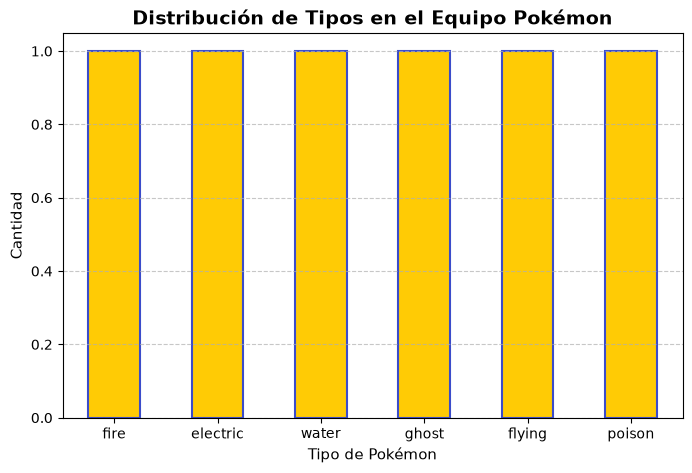

In [3]:
plt.figure(figsize=(8, 5))

# Dibujar el gráfico de barras por tipos
conteo_tipos.plot(kind='bar', color='#ffcb05', edgecolor='#3b4cca', linewidth=1.5)

# Títulos y estilos
plt.title('Distribución de Tipos en el Equipo Pokémon', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Pokémon', fontsize=11)
plt.ylabel('Cantidad', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la imagen para el entregable
plt.savefig('grafico.png', bbox_inches='tight', dpi=300)
plt.show()